In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import pipeline
import time

In [2]:
from datasets import load_dataset
df = load_dataset("mteb/emotion")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.63k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/2.23M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/276k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/279k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
print(df['train'][0])
print(df['validation'][0])
print(df['test'][0])

{'text': 'i didnt feel humiliated', 'label': 0, 'label_text': 'sadness'}
{'text': 'im feeling quite sad and sorry for myself but ill snap out of it soon', 'label': 0, 'label_text': 'sadness'}
{'text': 'im feeling rather rotten so im not very ambitious right now', 'label': 0, 'label_text': 'sadness'}


In [4]:
df_train = df['train'].to_pandas()
df_test = pd.concat([df['test'].to_pandas(), df['validation'].to_pandas()], axis = 0)

label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label_dict = {i: name for i, name in enumerate(label_names)}

X_train_text = df_train['text']
y_train = df_train['label']
X_test_text = df_test['text']
y_test = df_test['label']

print(f"Размер обучающей выборки: {len(df_train)}")
print(f"Размер тестовой выборки: {len(df_test)}")
print(f"Пример текста: {X_train_text.iloc[10]}")
print(f"Метка примера: {y_train.iloc[10]} ({label_dict[y_train.iloc[10]]})")

Размер обучающей выборки: 16000
Размер тестовой выборки: 4000
Пример текста: i feel like i have to make the suffering i m seeing mean something
Метка примера: 0 (sadness)


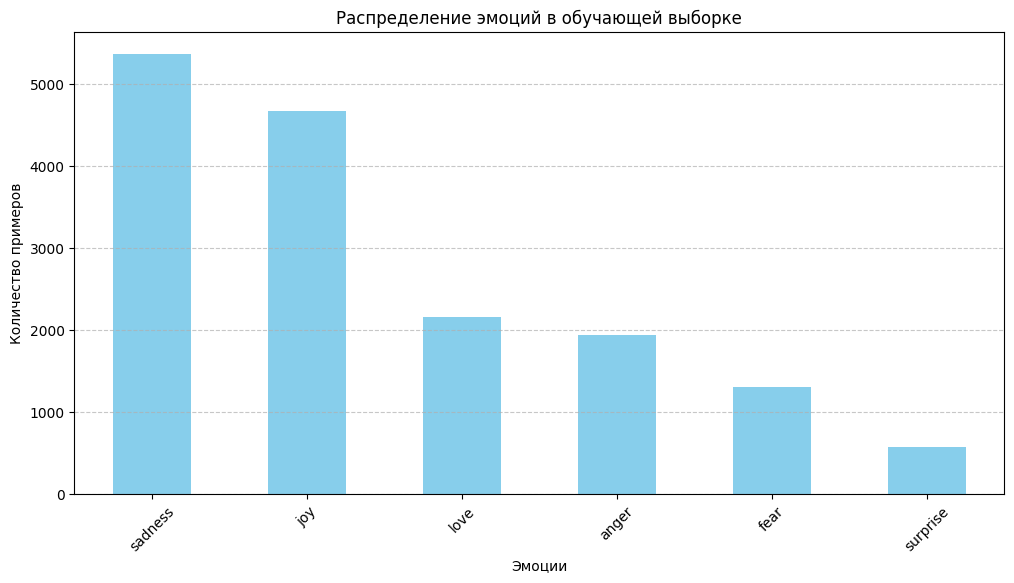

In [5]:
import matplotlib.pyplot as plt

emotion_counts = y_train.value_counts()

plt.figure(figsize=(12, 6))
emotion_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение эмоций в обучающей выборке')
plt.xlabel('Эмоции')
plt.ylabel('Количество примеров')
plt.xticks(ticks=range(len(label_names)), labels=[label_dict[i] for i in range(len(label_names))], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

results = {}

In [7]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test_true):
    print(f"Обучение модели: {name}")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    print(f"Предсказание модели: {name}")
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time

    accuracy = accuracy_score(y_test_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_true, y_pred, average='weighted')

    print(f"Результаты для {name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1-score (weighted): {f1:.4f}")
    print(f"  Время обучения: {train_time:.2f} сек")
    print(f"  Время предсказания: {pred_time:.2f} сек (на {len(y_test_true)} примерах)")
    print(classification_report(y_test_true, y_pred, target_names=label_names, zero_division=0))
    print()
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
            "train_time": train_time, "pred_time": pred_time / len(y_test_true)}

In [8]:
results['SVM'] = evaluate_model('SVM', SVC(kernel='linear'), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: SVM
Предсказание модели: SVM
Результаты для SVM:
  Accuracy: 0.8868
  Precision (weighted): 0.8860
  Recall (weighted): 0.8868
  F1-score (weighted): 0.8859
  Время обучения: 19.17 сек
  Время предсказания: 3.06 сек (на 4000 примерах)
              precision    recall  f1-score   support

     sadness       0.93      0.91      0.92      1131
         joy       0.89      0.93      0.91      1399
        love       0.82      0.76      0.79       337
       anger       0.89      0.89      0.89       550
        fear       0.84      0.85      0.84       436
    surprise       0.80      0.67      0.73       147

    accuracy                           0.89      4000
   macro avg       0.86      0.84      0.85      4000
weighted avg       0.89      0.89      0.89      4000




In [9]:
results["Naive Bayes"] = evaluate_model("Naive Bayes", MultinomialNB(), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: Naive Bayes
Предсказание модели: Naive Bayes
Результаты для Naive Bayes:
  Accuracy: 0.7605
  Precision (weighted): 0.8050
  Recall (weighted): 0.7605
  F1-score (weighted): 0.7274
  Время обучения: 0.00 сек
  Время предсказания: 0.00 сек (на 4000 примерах)
              precision    recall  f1-score   support

     sadness       0.73      0.93      0.82      1131
         joy       0.72      0.97      0.83      1399
        love       0.99      0.23      0.37       337
       anger       0.96      0.57      0.72       550
        fear       0.90      0.51      0.65       436
    surprise       0.92      0.08      0.15       147

    accuracy                           0.76      4000
   macro avg       0.87      0.55      0.59      4000
weighted avg       0.81      0.76      0.73      4000




In [10]:
results["KNN"] = evaluate_model("KNN", KNeighborsClassifier(n_neighbors=5), X_train_tfidf, y_train, X_test_tfidf, y_test)

Обучение модели: KNN
Предсказание модели: KNN
Результаты для KNN:
  Accuracy: 0.7525
  Precision (weighted): 0.7668
  Recall (weighted): 0.7525
  F1-score (weighted): 0.7443
  Время обучения: 0.00 сек
  Время предсказания: 1.45 сек (на 4000 примерах)
              precision    recall  f1-score   support

     sadness       0.79      0.81      0.80      1131
         joy       0.70      0.89      0.79      1399
        love       0.84      0.45      0.59       337
       anger       0.83      0.59      0.69       550
        fear       0.72      0.69      0.70       436
    surprise       0.94      0.41      0.58       147

    accuracy                           0.75      4000
   macro avg       0.80      0.64      0.69      4000
weighted avg       0.77      0.75      0.74      4000




In [11]:
transformer_model_name = "bhadresh-savani/distilbert-base-uncased-emotion"

emotion_classifier = pipeline("text-classification", model=transformer_model_name, tokenizer=transformer_model_name, device=0)

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [12]:
name_to_id_dict = {name: i for i, name in enumerate(label_names)}

start_time = time.time()
transformer_preds_raw = emotion_classifier(X_test_text.tolist(), batch_size=32)
pred_time_transformer = time.time() - start_time

In [13]:
y_pred_transformer = [name_to_id_dict[pred['label']] for pred in transformer_preds_raw]

accuracy_transformer = accuracy_score(y_test, y_pred_transformer)
precision_t, recall_t, f1_t, _ = precision_recall_fscore_support(y_test, y_pred_transformer, average='weighted', zero_division=0)

In [14]:
print(f"Результаты для {transformer_model_name}:")
print(f"  Accuracy: {accuracy_transformer:.4f}")
print(f"  Precision (weighted): {precision_t:.4f}")
print(f"  Recall (weighted): {recall_t:.4f}")
print(f"  F1-score (weighted): {f1_t:.4f}")
print(f"  Время предсказания: {pred_time_transformer:.2f} сек (на {len(y_test)} примерах)")
print(classification_report(y_test, y_pred_transformer, target_names=label_names, zero_division=0))

results['distilbert'] = {
    "accuracy": accuracy_transformer,
    "precision": precision_t,
    "recall": recall_t,
    "f1": f1_t,
    "train_time": "N/A (pre-trained)",
    "pred_time": pred_time_transformer / len(y_test)
}

Результаты для bhadresh-savani/distilbert-base-uncased-emotion:
  Accuracy: 0.9305
  Precision (weighted): 0.9309
  Recall (weighted): 0.9305
  F1-score (weighted): 0.9306
  Время предсказания: 225.35 сек (на 4000 примерах)
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.97      1131
         joy       0.95      0.95      0.95      1399
        love       0.83      0.85      0.84       337
       anger       0.94      0.92      0.93       550
        fear       0.87      0.92      0.89       436
    surprise       0.83      0.76      0.79       147

    accuracy                           0.93      4000
   macro avg       0.90      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



In [15]:
#Сводная таблица результатов
print("\nСводная таблица результатов:")
results_df = pd.DataFrame(results).T
results_df['pred_time_per_sample_ms'] = results_df['pred_time'] * 1000
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'train_time', 'pred_time_per_sample_ms']]
results_df = results_df.sort_values(by='f1', ascending=False)
print(results_df)


Сводная таблица результатов:
            accuracy precision   recall        f1         train_time  \
distilbert    0.9305  0.930937   0.9305  0.930564  N/A (pre-trained)   
SVM          0.88675   0.88604  0.88675  0.885914          19.173079   
KNN           0.7525  0.766813   0.7525   0.74429           0.001916   
Naive Bayes   0.7605  0.805047   0.7605  0.727439           0.004337   

            pred_time_per_sample_ms  
distilbert                 56.33862  
SVM                        0.764136  
KNN                        0.362104  
Naive Bayes                0.000214  
